# Population Analysis

In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load dataset from the CSO API

In [192]:
url = "https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/FY006A/CSV/1.0/en"
df = pd.read_csv(url)
df.tail(3)

,STATISTIC,Statistic Label,TLIST(A1),CensusYear,C02199V02655,Sex,C02076V03371,Single Year of Age,C03789V04537,Administrative Counties,UNIT,VALUE
9789,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-149d-13a3-e055-000000000001,Cavan County Council,Number,12
9790,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-14a4-13a3-e055-000000000001,Donegal County Council,Number,31
9791,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-1495-13a3-e055-000000000001,Monaghan County Council,Number,7


## Prepare data for analysis

### Filter out rows where sex is Both sexes and rows for individual regions

In [193]:
df = df[df['Sex'] != 'Both sexes']
df = df[df['Administrative Counties'] == 'Ireland']
df.head(3)

,STATISTIC,Statistic Label,TLIST(A1),CensusYear,C02199V02655,Sex,C02076V03371,Single Year of Age,C03789V04537,Administrative Counties,UNIT,VALUE
3264,FY006AC01,Population,2022,2022,1,Male,-,All ages,IE0,Ireland,Number,2544549
3296,FY006AC01,Population,2022,2022,1,Male,200,Under 1 year,IE0,Ireland,Number,29610
3328,FY006AC01,Population,2022,2022,1,Male,001,1 year,IE0,Ireland,Number,28875


### Review columns and remove unnecesary ones

In [194]:
headers = df.columns.tolist
headers

<bound method IndexOpsMixin.tolist of Index(['STATISTIC', 'Statistic Label', 'TLIST(A1)', 'CensusYear',
       'C02199V02655', 'Sex', 'C02076V03371', 'Single Year of Age',
       'C03789V04537', 'Administrative Counties', 'UNIT', 'VALUE'],
      dtype='object')>

In [195]:
# Remove columns not required for analysis
drop_col_list = ['STATISTIC', 'Statistic Label','TLIST(A1)','CensusYear','C02199V02655','C02076V03371','C03789V04537','UNIT']
df.drop(columns=drop_col_list, inplace=True)
print (df.head(3))

       Sex Single Year of Age Administrative Counties    VALUE
3264  Male           All ages                 Ireland  2544549
3296  Male       Under 1 year                 Ireland    29610
3328  Male             1 year                 Ireland    28875


### Format Single Year of Age column to contain only digits

In [196]:
# Remove All ages rows
df = df[df["Single Year of Age"] != 'All ages']
print (df.head(3))

# Replace "Under 1 year" with "0"
df["Single Year of Age"] = df["Single Year of Age"].str.replace("Under 1 year","0")

       Sex Single Year of Age Administrative Counties  VALUE
3296  Male       Under 1 year                 Ireland  29610
3328  Male             1 year                 Ireland  28875
3360  Male            2 years                 Ireland  30236


In [197]:
# Replace non-digit characters with an empty string
df["Single Year of Age"] = df["Single Year of Age"].str.replace("\D", "", regex=True)
print (df.head(3))

# Check data by saving to a CSV file
df.to_csv("population_for_analysis.csv")

       Sex Single Year of Age Administrative Counties  VALUE
3296  Male                  0                 Ireland  29610
3328  Male                  1                 Ireland  28875
3360  Male                  2                 Ireland  30236


### Prepare data types for analysis

In [198]:
# Convert the "Single Year of Age" column to integer type for further analysis
df["Single Year of Age"] = df["Single Year of Age"].astype(int)
print (df.head(3))
df.info()

       Sex  Single Year of Age Administrative Counties  VALUE
3296  Male                   0                 Ireland  29610
3328  Male                   1                 Ireland  28875
3360  Male                   2                 Ireland  30236
<class 'pandas.core.frame.DataFrame'>
Index: 202 entries, 3296 to 9760
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Sex                      202 non-null    object
 1   Single Year of Age       202 non-null    int64 
 2   Administrative Counties  202 non-null    object
 3   VALUE                    202 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 7.9+ KB


# Part 1

## Weighted Mean Age By Sex

Per lecture 5 materials, **weighted mean = sum(age * population at that age) / sum(populations at age)**.

Initially, I calculated weighted average for each sex separately using `numpy.average()` ([official documentation](https://numpy.org/devdocs/reference/generated/numpy.average.html)). However, that apprach felt manual. After doing more research, I found the following [Python & VBA](https://pythonandvba.com/blog/weighted-average-calculation-in-pandas/) tutorial, which demonstrated a more elegat way to compute weighted averages in Pandas using `groupby.()` function.

In [199]:
# Create a function to calculate weighted average
# The function takes three arguments: values, ages, sex
def calc_weighted_avg(values, ages, sex): 

    # Calculate weighted values multiplying ages by number of population at that age
    weighted = ages * values
    
    # Return calculated of the weighted average by sex
    return weighted.groupby(sex).sum() / values.groupby(sex).sum()

# Call the function
calc_weighted_avg(df['VALUE'], df['Single Year of Age'], df['Sex'])

Sex
Female    38.939796
Male      37.739448
dtype: float64

## The Difference Between The Sexes By Age

In order to examine differences by sex and age, I pivoted the data so that Sex becomes the index and the male and female population counts appear as separate columns. I used `pd.pivot_table()` for this step, drawing on the lecture materials as well as a tutorial from [GeeksforGeeks](https://www.geeksforgeeks.org/python/python-pandas-pivot_table/).

### Pivot data for further analysis

In [200]:
# Create a pivot table for analysis
df_analysis = pd.pivot_table(df, values = 'VALUE', index='Single Year of Age', columns = 'Sex')
print (df_analysis.head(3))

#df_analysis.to_csv("population_for_analysis.csv")

Sex                 Female   Male
Single Year of Age               
0                    28186  29610
1                    27545  28875
2                    28974  30236


### Add a new column to show delta between the number of males and females at each age

To show the explicit variance between male and female populations, I created a new column representing the difference between the two population counts by subtracting the number of females from the number of males at each age

In [201]:
# Create a new column to show the difference between male and female populations at each age
df_analysis['Age Diff'] = df_analysis['Male'] - df_analysis['Female']

# Convert the 'Age Diff' column to integer type
df_analysis['Age Diff'] = df_analysis['Age Diff'].astype(int)
print (df_analysis.head(3))

Sex                 Female   Male  Age Diff
Single Year of Age                         
0                    28186  29610      1424
1                    27545  28875      1330
2                    28974  30236      1262


### Visualize data

To visualize the data, I created plots using `Matplotlib` library that clearly show how male and female population counts vary across different years of age. 

Initially, I used a stacked bar plot, but I found it difficult to compare the male and female populations at each age. To improve readability, I switched to a clustered bar plot, which makes the differences between sexes much easier to see.

For plotting, I used various resources, including:
- [Geekforgeeks](https://www.geeksforgeeks.org/python/create-a-grouped-bar-plot-in-matplotlib/) tutorial;
- Official [Matplotlib](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html) documentation on bar plots;
- ChatGPT for minor fixes.

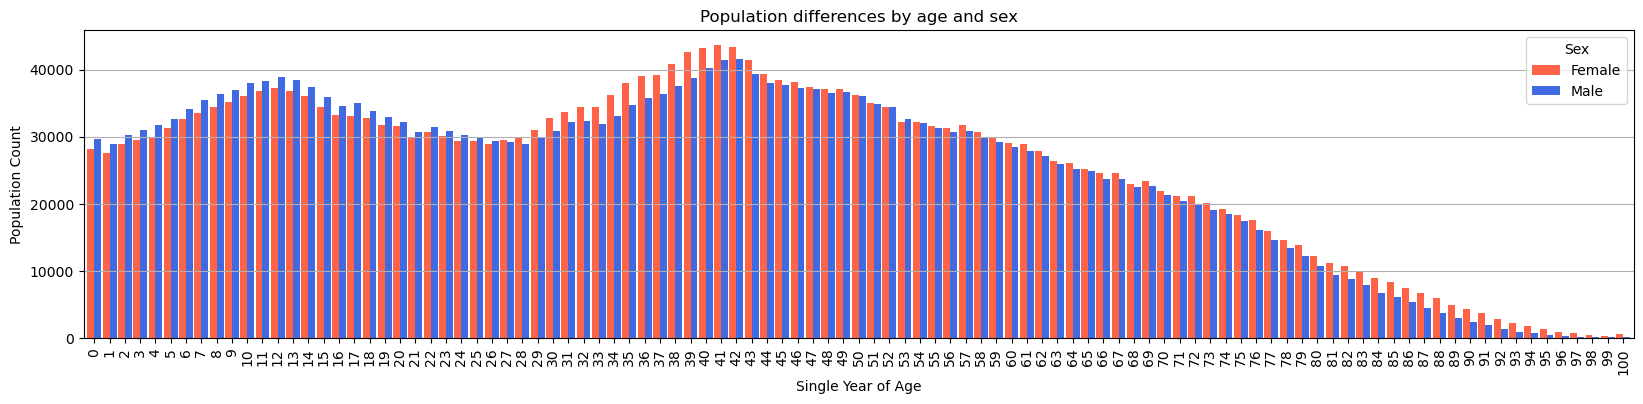

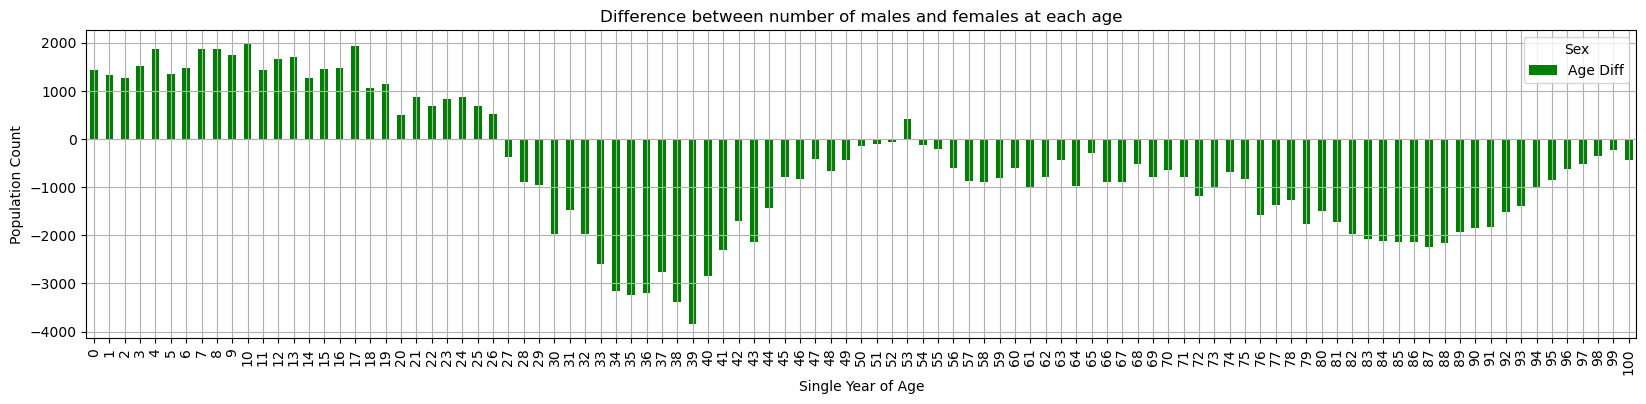

In [202]:
# Create a clustered bar plot passing both sexes as y values
# This show the differences between male and female populations at each age
ax1 = df_analysis.plot.bar(y=['Female', 'Male'], width=0.9, color={"Male": "royalblue", "Female": "tomato"}, figsize=(20, 4))
# Add titles, labels, grid
ax1.set_title('Population differences by age and sex')   
ax1.set_ylabel('Population Count')
ax1.grid(axis='y')

# Create a separate bar plot to show the age delta between male and female populations
ax2 = df_analysis.plot.bar(y=['Age Diff'], color = 'green', figsize=(20, 4))
# Add titles, labels, grid
ax2.set_title('Difference between number of males and females at each age')   
ax2.set_ylabel('Population Count')
ax2.grid(True)


## Charts intepretation
From the charts, we can observe that:
- There are more males than females in Ireland from under 1 year up to 26 years old;
- There are more females than males from age 27 onward, where females generally outnumber males at each age;
    - there's one exception for the age of 54, which indicates males dominance;
- Male populations are particularly dominant between ages under 1 year–19;
- Female populations are particularly dominant between ages 30–44 and again from age 77 up to 93.

# Part 2

## People within 5 years of age analysis

To extract the populations within 5 years of age 35 (i.e., ages 30–40), I used the filtering approach based on guidance from [Geeks For Geeks](https://www.geeksforgeeks.org/python/filter-pandas-dataframe-with-multiple-conditions/?utm_source=chatgpt.com) tutorial - Filter Pandas Dataframe with multiple conditions. 

In [ ]:
# Create Age variable
age_35 = 35

# Filter for people within 5 years of that age
age_group = df[(df['Single Year of Age'] >= age_35 - 5) & 
                (df['Single Year of Age'] <= age_35 + 5)]

# Show filtered age group
age_group

,Sex,Single Year of Age,Administrative Counties,VALUE
4256,Male,30,Ireland,30858
4288,Male,31,Ireland,32237
4320,Male,32,Ireland,32413
4352,Male,33,Ireland,31888
4384,Male,34,Ireland,33121
4416,Male,35,Ireland,34695
4448,Male,36,Ireland,35828
4480,Male,37,Ireland,36427
4512,Male,38,Ireland,37513
4544,Male,39,Ireland,38749


Now we can aggregate populations by sex using `groupby()` function.

In [207]:
# Sum the population for each sex
sex_sums = age_group.groupby('Sex')['VALUE'].sum()

sex_sums

Sex
Female    414506
Male      384030
Name: VALUE, dtype: int64

In [209]:
# Calculate difference (Male minus Female)
population_difference = sex_sums['Male'] - sex_sums['Female']

population_difference

-30476

There are 30,476 more females than males in the population within 5 years of age 35.

## End